In [2]:
!pip install pandas numpy matplotlib seaborn nltk textblob wordcloud scikit-learn

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.2 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   --------------------------------- ------ 524.3/625.0 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 625.0/625.0 kB 1.3 MB/s eta 0:00:00

   -----------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ANUPAM\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ANUPAM\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ANUPAM\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ANUPAM\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ANUPAM\AppData\Roaming\nltk_data...


True

In [5]:
df = pd.read_csv("3) Sentiment dataset.csv")

In [6]:
print("Dataset Shape:", df.shape)

Dataset Shape: (732, 15)


In [7]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [8]:
df.tail()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20
731,732,736,Organizing a virtual talent show during challe...,Happy,2020-11-15 15:15:00,VirtualTalentShowSuccessHighSchool,Instagram,#VirtualEntertainment #HighSchoolPositivity,24.0,47.0,USA,2020,11,15,15


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    str    
 3   Sentiment     732 non-null    str    
 4   Timestamp     732 non-null    str    
 5   User          732 non-null    str    
 6   Platform      732 non-null    str    
 7   Hashtags      732 non-null    str    
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    str    
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), str(7)
memory usage: 85.9 KB


In [10]:
df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

In [11]:
df.isnull().sum()

Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [19]:
print(df.columns.tolist())

['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


In [20]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [21]:
print(df.columns.tolist())
df.head()

['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User', 'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month', 'Day', 'Hour']


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [22]:
text_column = 'Text'
label_column = 'Sentiment'

print("Text column:", text_column)
print("Label column:", label_column)

Text column: Text
Label column: Sentiment


In [23]:
print(df[label_column].value_counts())

Sentiment
Positive         44
Joy              42
Excitement       32
Contentment      14
Neutral          14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64


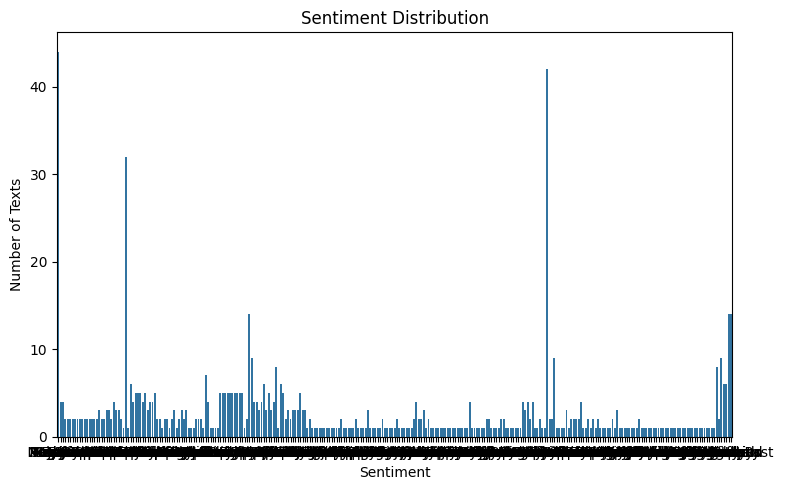

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x=label_column)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")

plt.tight_layout()

plt.savefig("sentiment_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
df = df.drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [26]:
df.head()

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [27]:
print(df.isnull().sum())

Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


In [28]:
df = df.dropna(subset=['Text', 'Sentiment'])

In [29]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 20
Duplicates after: 0


In [30]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove HTML
    text = re.sub(r'<.*?>', '', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Tokenization
    words = nltk.word_tokenize(text)
    
    # Stopword removal + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    
    return ' '.join(words)

In [31]:
df['clean_text'] = df['Text'].apply(preprocess_text)

In [32]:
df[['Text', 'clean_text']].head(10)

,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout 💪
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little thing life
6,Rainy days call for cozy blankets and hot coc...,rainy day call cozy blanket hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussion heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibe beach day


In [33]:
df[['Text', 'clean_text']].head(10)

,Text,clean_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout 💪
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little thing life
6,Rainy days call for cozy blankets and hot coc...,rainy day call cozy blanket hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussion heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibe beach day


In [34]:
from collections import Counter

all_words = ' '.join(df['clean_text'])

word_counts = Counter(all_words.split())

common_words = word_counts.most_common(20)

print(common_words)

[('new', 43), ('life', 35), ('day', 29), ('joy', 28), ('feeling', 27), ('moment', 27), ('like', 27), ('friend', 26), ('heart', 24), ('dream', 23), ('world', 22), ('night', 22), ('art', 21), ('time', 20), ('beauty', 20), ('laughter', 20), ('journey', 20), ('emotion', 20), ('echo', 20), ('nature', 19)]


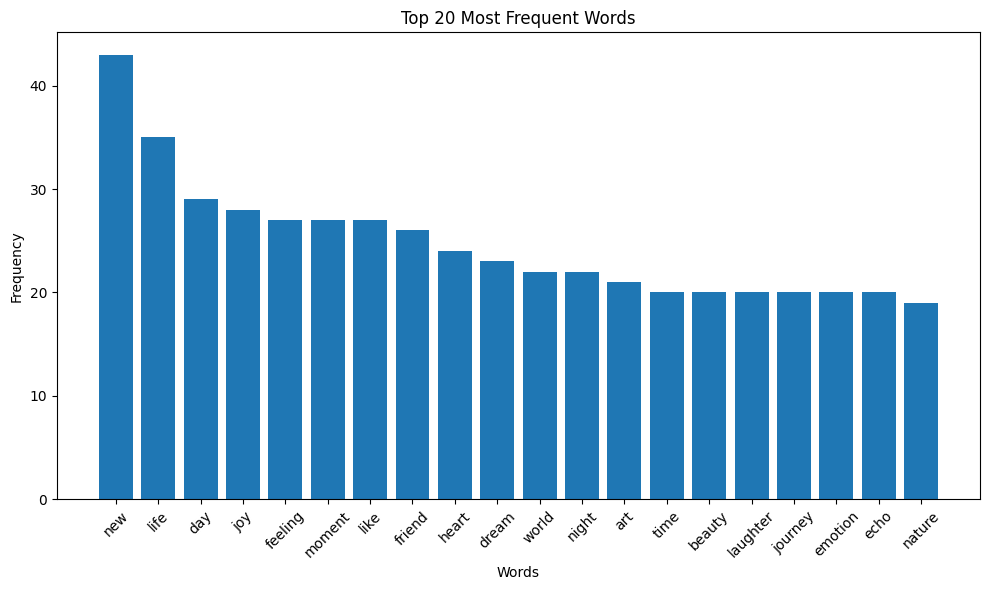

In [35]:
words = [word[0] for word in common_words]
counts = [word[1] for word in common_words]

plt.figure(figsize=(10,6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("top_20_words.png", dpi=300, bbox_inches="tight")

plt.show()

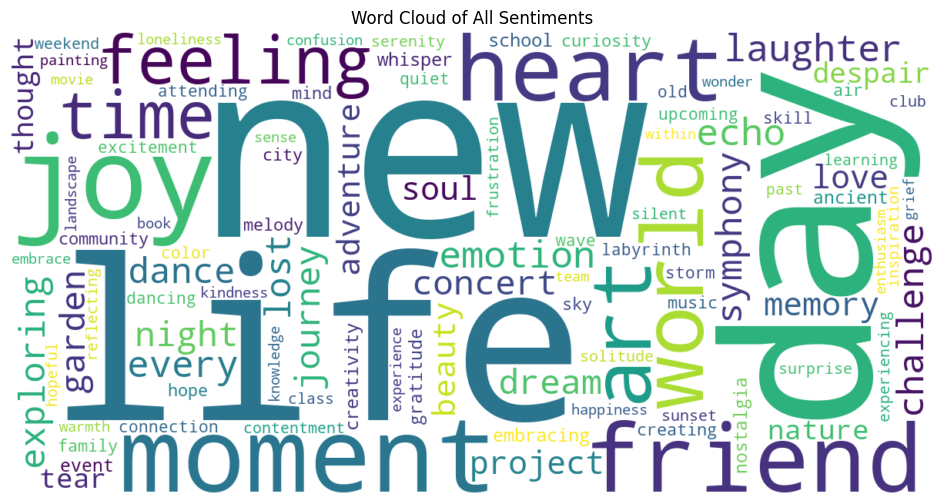

In [36]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')
plt.title("Word Cloud of All Sentiments")

plt.savefig(
    "wordcloud_all_sentiments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
print(df['Sentiment'].value_counts())

Sentiment
Positive         44
Joy              42
Excitement       32
Neutral          14
Happy            14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64


In [38]:
positive_text = ' '.join(
    df[df['Sentiment'] == 'Positive']['clean_text']
)

negative_text = ' '.join(
    df[df['Sentiment'] == 'Negative']['clean_text']
)

neutral_text = ' '.join(
    df[df['Sentiment'] == 'Neutral']['clean_text']
)

In [39]:
if positive_text.strip():

    wc_positive = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=100
    ).generate(positive_text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_positive, interpolation='bilinear')
    plt.axis('off')
    plt.title("Positive Sentiment Word Cloud")

    plt.savefig(
        "wordcloud_positive.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [40]:
if negative_text.strip():

    wc_negative = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=100
    ).generate(negative_text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_negative, interpolation='bilinear')
    plt.axis('off')
    plt.title("Negative Sentiment Word Cloud")

    plt.savefig(
        "wordcloud_negative.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [41]:
if neutral_text.strip():

    wc_neutral = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        max_words=100
    ).generate(neutral_text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc_neutral, interpolation='bilinear')
    plt.axis('off')
    plt.title("Neutral Sentiment Word Cloud")

    plt.savefig(
        "wordcloud_neutral.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [42]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df['TextBlob_Sentiment'] = df['Text'].apply(get_sentiment)

df[['Text', 'Sentiment', 'TextBlob_Sentiment']].head(10)

,Text,Sentiment,TextBlob_Sentiment
0,Enjoying a beautiful day at the park! ...,Positive,Positive
1,Traffic was terrible this morning. ...,Negative,Negative
2,Just finished an amazing workout! 💪 ...,Positive,Positive
3,Excited about the upcoming weekend getaway! ...,Positive,Positive
4,Trying out a new recipe for dinner tonight. ...,Neutral,Positive
5,Feeling grateful for the little things in lif...,Positive,Negative
6,Rainy days call for cozy blankets and hot coc...,Positive,Positive
7,The new movie release is a must-watch! ...,Positive,Positive
8,Political discussions heating up on the timel...,Negative,Neutral
9,Missing summer vibes and beach days. ...,Neutral,Negative


In [43]:
print(df['TextBlob_Sentiment'].value_counts())

TextBlob_Sentiment
Neutral     314
Positive    274
Negative    124
Name: count, dtype: int64


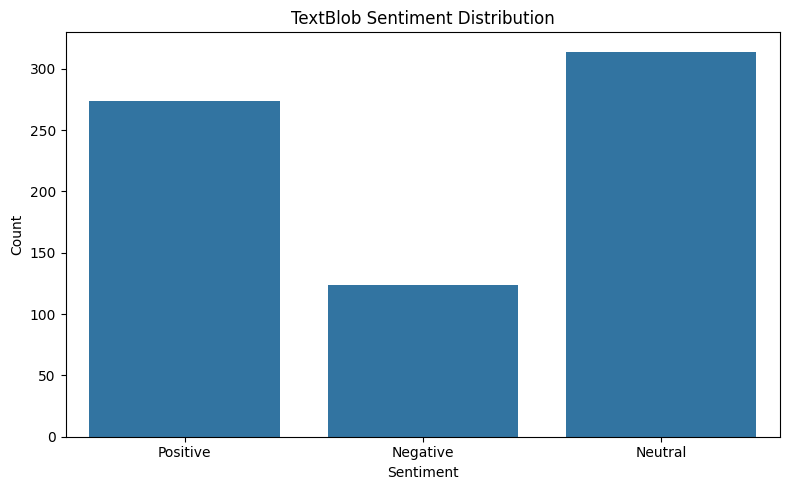

In [44]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='TextBlob_Sentiment')
plt.title("TextBlob Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("textblob_sentiment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
comparison = pd.crosstab(
    df['Sentiment'],
    df['TextBlob_Sentiment']
)

print(comparison)

TextBlob_Sentiment  Negative  Neutral  Positive
Sentiment                                      
Acceptance                 0        3         0
Acceptance                 1        3         1
Accomplishment             0        0         3
Admiration                 0        0         1
Admiration                 0        1         1
...                      ...      ...       ...
Wonder                     0        1         0
Wonder                     0        1         0
Wonderment                 0        1         0
Yearning                   1        1         0
Zest                       0        0         2

[279 rows x 3 columns]


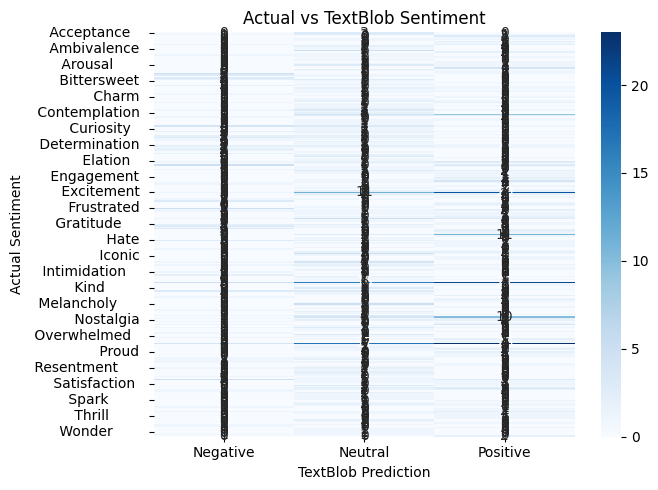

In [46]:
plt.figure(figsize=(7,5))
sns.heatmap(comparison, annot=True, fmt='d', cmap='Blues')
plt.title("Actual vs TextBlob Sentiment")
plt.xlabel("TextBlob Prediction")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.savefig("actual_vs_textblob.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
print("Actual labels:")
print(y_test.value_counts())

print("\nPredicted labels:")
print(pd.Series(y_pred).value_counts())

Actual labels:
Sentiment
Positive      9
Joy           8
Excitement    7
Curiosity     6
Frustrated    4
             ..
Isolation     1
Jealousy      1
Enthusiasm    1
Shame         1
Pride         1
Name: count, Length: 80, dtype: int64

Predicted labels:
Joy           62
Positive      61
Excitement    17
Acceptance     1
Serenity       1
Gratitude      1
Name: count, dtype: int64


In [59]:
print("Model classes:")
print(model.classes_)

Model classes:
['Acceptance' 'Accomplishment' 'Admiration' 'Adoration' 'Adventure'
 'Affection' 'Amazement' 'Ambivalence' 'Amusement' 'Anger' 'Anticipation'
 'Anxiety' 'Appreciation' 'Apprehensive' 'ArtisticBurst' 'Awe' 'Bad'
 'Betrayal' 'Bitter' 'Bitterness' 'Bittersweet' 'Boredom' 'Breakthrough'
 'Calmness' 'Captivation' 'Celebration' 'Celestial Wonder' 'Challenge'
 'Charm' 'Colorful' 'Compassion' 'Compassionate' 'Confidence' 'Confident'
 'Confusion' 'Contentment' 'Coziness' 'Creative Inspiration' 'Creativity'
 'Culinary Adventure' 'CulinaryOdyssey' 'Curiosity' 'Darkness' 'Dazzle'
 'Desolation' 'Despair' 'Desperation' 'Determination' 'Devastated'
 'Disappointed' 'Disappointment' 'Disgust' 'Dismissive' 'DreamChaser'
 'Ecstasy' 'Elation' 'Elegance' 'Embarrassed' 'Emotion' 'EmotionalStorm'
 'Empathetic' 'Empowerment' 'Enchantment' 'Energy' 'Engagement'
 'Enthusiasm' 'Envious' 'Envy' 'Euphoria' 'Excitement' 'Exhaustion'
 'Exploration' 'Fear' 'Fearful' 'FestiveJoy' 'Free-spirited' 'Friend

In [61]:
print("Actual labels:")
print(y_test.value_counts())

print("\nPredicted labels:")
print(pd.Series(y_pred).value_counts())

print("\nModel classes:")
print(model.classes_)

Actual labels:
Sentiment
Positive      9
Joy           8
Excitement    7
Curiosity     6
Frustrated    4
             ..
Isolation     1
Jealousy      1
Enthusiasm    1
Shame         1
Pride         1
Name: count, Length: 80, dtype: int64

Predicted labels:
Joy           62
Positive      61
Excitement    17
Acceptance     1
Serenity       1
Gratitude      1
Name: count, dtype: int64

Model classes:
['Acceptance' 'Accomplishment' 'Admiration' 'Adoration' 'Adventure'
 'Affection' 'Amazement' 'Ambivalence' 'Amusement' 'Anger' 'Anticipation'
 'Anxiety' 'Appreciation' 'Apprehensive' 'ArtisticBurst' 'Awe' 'Bad'
 'Betrayal' 'Bitter' 'Bitterness' 'Bittersweet' 'Boredom' 'Breakthrough'
 'Calmness' 'Captivation' 'Celebration' 'Celestial Wonder' 'Challenge'
 'Charm' 'Colorful' 'Compassion' 'Compassionate' 'Confidence' 'Confident'
 'Confusion' 'Contentment' 'Coziness' 'Creative Inspiration' 'Creativity'
 'Culinary Adventure' 'CulinaryOdyssey' 'Curiosity' 'Darkness' 'Dazzle'
 'Desolation' 'Despair'

In [62]:
print(df['Sentiment'].value_counts())
print("\nUnique values:")
print(df['Sentiment'].unique())

Sentiment
Positive         44
Joy              42
Excitement       32
Neutral          14
Happy            14
                 ..
Boredom           1
Indifference      1
Disgust           1
Relief            1
Positive          1
Name: count, Length: 279, dtype: int64

Unique values:
<StringArray>
[   ' Positive  ',    ' Negative  ',    ' Neutral   ', ' Anger        ',
 ' Fear         ', ' Sadness      ', ' Disgust      ', ' Happiness    ',
 ' Joy          ', ' Love         ',
 ...
      ' Disgust ',       ' Relief ',     ' Positive ',  ' Embarrassed ',
  ' Mischievous ',          ' Sad ',         ' Hate ',          ' Bad ',
      ' Neutral ',        ' Happy ']
Length: 279, dtype: str


In [64]:
# Create a copy
data = df[['Text', 'Sentiment']].copy()

# Clean spaces
data['Sentiment'] = data['Sentiment'].astype(str).str.strip()

# Define Positive emotions
positive_labels = [
    'Positive',
    'Joy',
    'Excitement',
    'Happy',
    'Happiness',
    'Love',
    'Relief',
    'Pride',
    'Optimism',
    'Gratitude',
    'Admiration',
    'Amusement',
    'Hope',
    'Delight',
    'Contentment',
    'Enthusiasm',
    'Satisfaction'
]

# Define Negative emotions
negative_labels = [
    'Negative',
    'Anger',
    'Fear',
    'Sadness',
    'Disgust',
    'Boredom',
    'Hate',
    'Bad',
    'Sad',
    'Embarrassed',
    'Annoyance',
    'Frustration',
    'Guilt',
    'Shame',
    'Worry',
    'Anxiety',
    'Grief',
    'Regret'
]

# Convert to 3 classes
def convert_sentiment(label):
    if label in positive_labels:
        return 'Positive'
    elif label in negative_labels:
        return 'Negative'
    elif label == 'Neutral' or label == 'Indifference':
        return 'Neutral'
    else:
        return None

data['Final_Sentiment'] = data['Sentiment'].apply(convert_sentiment)

# Remove labels that could not be classified
data = data.dropna(subset=['Final_Sentiment'])

# Remove missing text
data = data.dropna(subset=['Text'])

# Remove empty text
data = data[data['Text'].astype(str).str.strip() != '']

print("Final dataset size:", len(data))

print("\nFinal Sentiment Distribution:")
print(data['Final_Sentiment'].value_counts())

Final dataset size: 312

Final Sentiment Distribution:
Final_Sentiment
Positive    214
Negative     74
Neutral      24
Name: count, dtype: int64


In [65]:
from sklearn.model_selection import train_test_split

X = data['Text'].astype(str)
y = data['Final_Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

Training samples: 249
Testing samples: 63

Training sentiment distribution:
Final_Sentiment
Positive    171
Negative     59
Neutral      19
Name: count, dtype: int64


In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (249, 3386)
TF-IDF testing shape: (63, 3386)


In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [68]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 79.37 %


In [69]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73        15
     Neutral       0.00      0.00      0.00         5
    Positive       0.81      0.91      0.86        43

    accuracy                           0.79        63
   macro avg       0.52      0.55      0.53        63
weighted avg       0.73      0.79      0.76        63



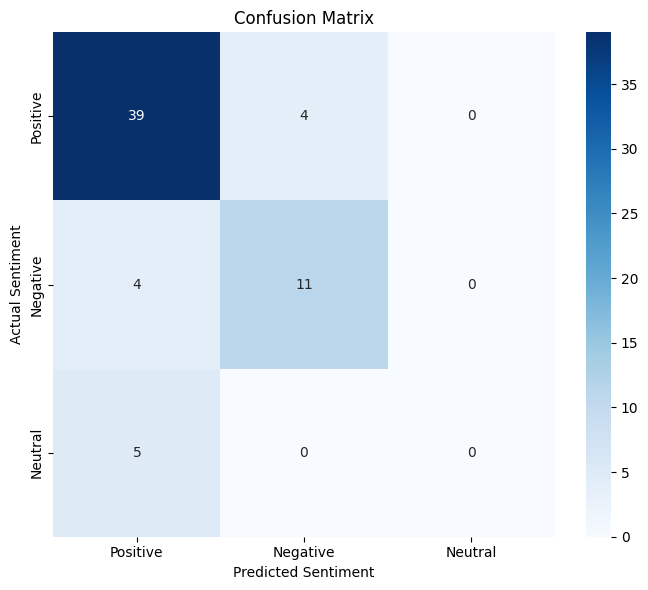

In [70]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['Positive', 'Negative', 'Neutral']
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Positive', 'Negative', 'Neutral'],
    yticklabels=['Positive', 'Negative', 'Neutral']
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [71]:
def predict_sentiment(text):
    vector = tfidf.transform([text])
    return model.predict(vector)[0]

print(predict_sentiment("I absolutely love this product!"))
print(predict_sentiment("This is the worst experience ever."))
print(predict_sentiment("The product is okay."))

Positive
Positive
Positive


In [72]:
results = pd.DataFrame({
    'Text': X_test.values,
    'Actual Sentiment': y_test.values,
    'Predicted Sentiment': y_pred
})

results.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

data.to_csv(
    "final_sentiment_dataset.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [73]:
from sklearn.model_selection import train_test_split

X = data['Text'].astype(str)
y = data['Final_Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining distribution:")
print(y_train.value_counts())


Training samples: 249
Testing samples: 63

Training distribution:
Final_Sentiment
Positive    171
Negative     59
Neutral      19
Name: count, dtype: int64


In [74]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (249, 3386)
Testing TF-IDF shape: (63, 3386)


In [75]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [76]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions completed!

First 10 predictions:
['Positive' 'Positive' 'Positive' 'Positive' 'Positive' 'Negative'
 'Positive' 'Negative' 'Positive' 'Positive']


In [77]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("================================")
print("MODEL ACCURACY")
print("================================")
print(f"Accuracy: {accuracy * 100:.2f}%")

MODEL ACCURACY
Accuracy: 79.37%


In [78]:
from sklearn.metrics import classification_report

print("================================")
print("CLASSIFICATION REPORT")
print("================================")

print(
    classification_report(
        y_test,
        y_pred,
        labels=['Positive', 'Negative', 'Neutral'],
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Positive       0.81      0.91      0.86        43
    Negative       0.73      0.73      0.73        15
     Neutral       0.00      0.00      0.00         5

    accuracy                           0.79        63
   macro avg       0.52      0.55      0.53        63
weighted avg       0.73      0.79      0.76        63



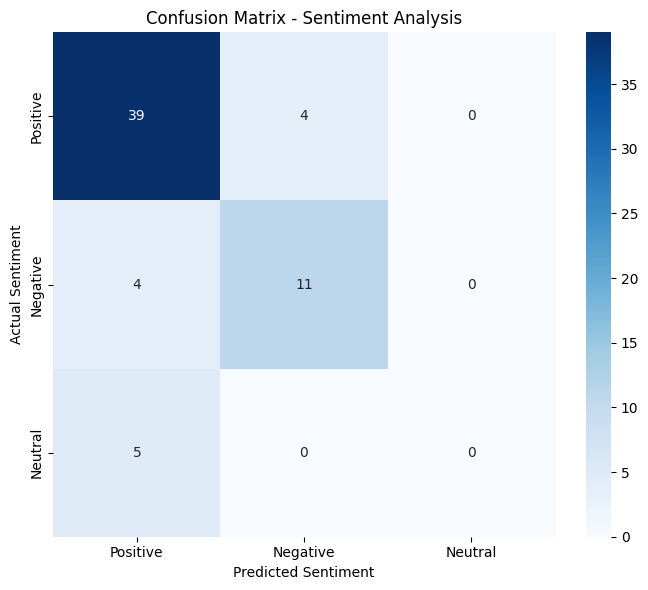

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

labels = ['Positive', 'Negative', 'Neutral']

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Sentiment Analysis")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
results = pd.DataFrame({
    'Text': X_test.values,
    'Actual Sentiment': y_test.values,
    'Predicted Sentiment': y_pred
})

print(results.head(15))

                                                 Text Actual Sentiment  \
0   Successfully completing a challenging coding p...         Positive   
1    Enjoying a beautiful day at the park!        ...         Positive   
2    Feeling optimistic about the week ahead.     ...         Positive   
3   Surrounded by the colors of joy, a canvas pain...         Positive   
4   Entered the kitchen with the intention to cook...         Negative   
5   Dealing with unfounded rumors circulating abou...         Negative   
6   In the symphony of excitement, each note is a ...         Positive   
7    Boredom lingers, a stagnant pool of indiffere...         Negative   
8    Rainy days call for cozy blankets and hot coc...         Positive   
9   Attending a workshop on time management to enh...          Neutral   
10   Productive day ticking off my to-do list.    ...         Positive   
11  Celebrating a friend's birthday with a surpris...         Positive   
12  Pride in achieving a personal mile

In [81]:
results.to_csv(
    "sentiment_analysis_results.csv",
    index=False
)

print("sentiment_analysis_results.csv saved successfully!")

sentiment_analysis_results.csv saved successfully!


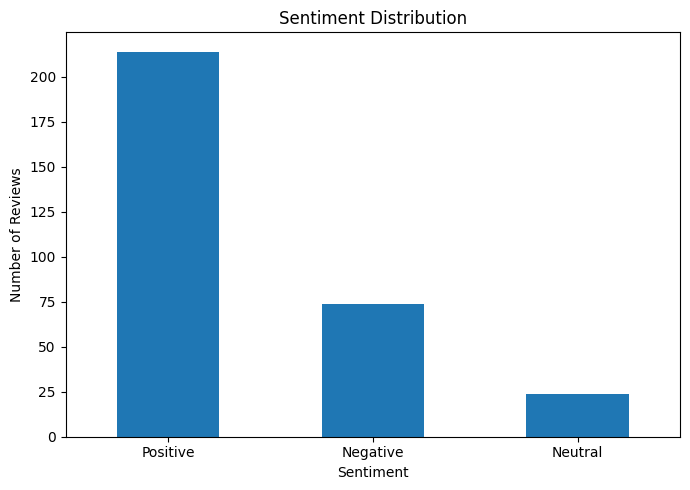

In [82]:
plt.figure(figsize=(7, 5))

data['Final_Sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "sentiment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

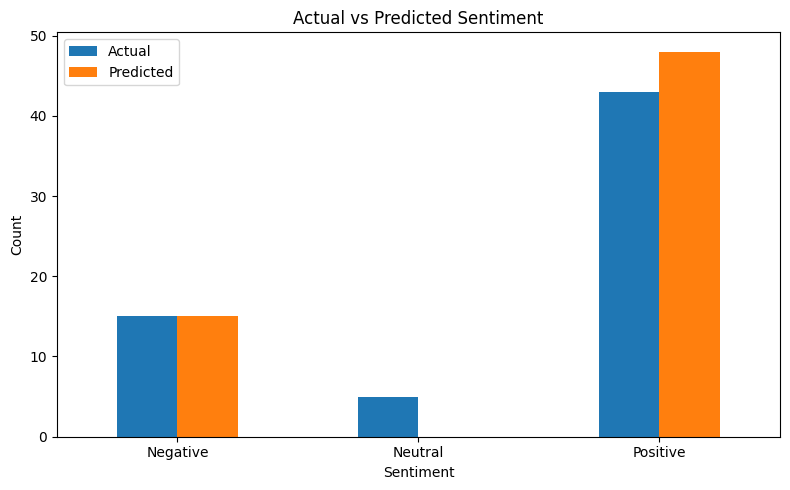

In [83]:
comparison = pd.DataFrame({
    'Actual': y_test.value_counts(),
    'Predicted': pd.Series(y_pred).value_counts()
}).fillna(0)

comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Actual vs Predicted Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [84]:
def predict_sentiment(text):
    text_vector = tfidf.transform([str(text)])
    prediction = model.predict(text_vector)[0]
    return prediction

In [85]:
print("Sentence 1:",
      predict_sentiment("I absolutely love this product, it is amazing!"))

print("Sentence 2:",
      predict_sentiment("This is the worst experience ever."))

print("Sentence 3:",
      predict_sentiment("The product is okay and average."))

Sentence 1: Positive
Sentence 2: Positive
Sentence 3: Positive


In [86]:
data.to_csv(
    "final_sentiment_dataset.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!


In [87]:
print("\n" + "=" * 50)
print("       SENTIMENT ANALYSIS - FINAL SUMMARY")
print("=" * 50)

print("Total dataset samples:", len(data))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nSentiment Classes:")
print(data['Final_Sentiment'].value_counts())

print("\nSaved Files:")
print("1. confusion_matrix.png")
print("2. sentiment_distribution.png")
print("3. actual_vs_predicted.png")
print("4. sentiment_analysis_results.csv")
print("5. final_sentiment_dataset.csv")
print("6. sentiment_model.pkl")
print("7. tfidf_vectorizer.pkl")

print("\nTask 3 completed!")


       SENTIMENT ANALYSIS - FINAL SUMMARY
Total dataset samples: 312
Training samples: 249
Testing samples: 63

Model Accuracy: 79.37%

Sentiment Classes:
Final_Sentiment
Positive    214
Negative     74
Neutral      24
Name: count, dtype: int64

Saved Files:
1. confusion_matrix.png
2. sentiment_distribution.png
3. actual_vs_predicted.png
4. sentiment_analysis_results.csv
5. final_sentiment_dataset.csv
6. sentiment_model.pkl
7. tfidf_vectorizer.pkl

Task 3 completed!
